In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# Generate synthetic dataset
np.random.seed(0)
n = 500

# Create correlated predictors
size_sqft = np.random.normal(loc=2000, scale=500, size=n)
num_rooms = size_sqft / 400 + np.random.normal(loc=0, scale=0.5, size=n)  # highly correlated with size
distance_city_center = np.random.normal(loc = 10, scale = 3, size = n)  # Independent Variable

# Price Function
price = 50000 + 100 * size_sqft + 10000 * num_rooms - 3000 * distance_city_center + np.random.normal(0, 50000, n)

In [4]:
# Combine the data into a df
df = pd.DataFrame({
    "Size_Sqft": size_sqft,
    "Num_Rooms": num_rooms,
    "Distance_City_Center": distance_city_center,
    "Price": price
})
df.head()

,Size_Sqft,Num_Rooms,Distance_City_Center,Price
0,2882.026173,7.396432,11.667888,377825.258039
1,2200.078604,5.483075,12.677422,280709.102754
2,2489.368992,6.771596,8.733056,357406.654449
3,3120.446600,7.684009,10.314142,378460.717581
4,2933.778995,7.160722,10.684160,338141.853175


In [5]:
# Check Correlation - Size and Rooms have 0.925 correlation - strong multicollinearity
corr_mat = df[["Size_Sqft", "Num_Rooms", "Distance_City_Center"]].corr()
print(corr_mat)

                      Size_Sqft  Num_Rooms  Distance_City_Center
Size_Sqft              1.000000   0.929475             -0.046299
Num_Rooms              0.929475   1.000000             -0.047085
Distance_City_Center  -0.046299  -0.047085              1.000000


In [6]:
# Calculate VIF
X = df[["Size_Sqft", "Num_Rooms", "Distance_City_Center"]]
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
pd.DataFrame({'Feature': X.columns, 'VIF': vif})
# Both Size and Rooms have VIF > 10, severe multicollinearity

,Feature,VIF
0,Size_Sqft,115.822693
1,Num_Rooms,109.893520
2,Distance_City_Center,7.314648


In [7]:
# Fit a linear Regression
X = df[["Size_Sqft", "Num_Rooms", "Distance_City_Center"]]
y = df["Price"]

lr = LinearRegression()
lr.fit(X, y)

pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

,Feature,Coefficient
0,Size_Sqft,99.691127
1,Num_Rooms,8029.006856
2,Distance_City_Center,-3850.233845


In [8]:
# Compare to Ridge Regression
ridge = Ridge(alpha=100)
ridge.fit(X, y)

pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
})

,Feature,Coefficient
0,Size_Sqft,108.736688
1,Num_Rooms,4361.205985
2,Distance_City_Center,-3766.973027


In [9]:
# Compare Model Performance
y_pred_lr = lr.predict(X)
y_pred_ridge = ridge.predict(X)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y, y_pred_lr)))
print("Ridge Regression RMSE:", np.sqrt(mean_squared_error(y, y_pred_ridge)))

Linear Regression RMSE: 48410.79820446743
Ridge Regression RMSE: 48444.474621468195


# Another example of Multicollinearity

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
# The correlation between square feet and num of bedrooms will create multicollinearity
np.random.seed(42)

n = 1000

square_feet = np.random.normal(loc=1500, scale=300, size=n)
num_bedrooms = (square_feet / 500 + np.random.normal(loc=0, scale=0.3, size=n)).round()
num_bathrooms = np.random.randint(low=1, high=4, size=n)
price = 50000 + 100 * square_feet + 10000 * num_bathrooms + np.random.normal(0, 20000, size=n)

# Put everything in a dataframe
df = pd.DataFrame({
    "price": price,
    "square_feet": square_feet,
    "num_bedrooms": num_bedrooms,
    "num_bathrooms": num_bathrooms
})
df.sample(5)

,price,square_feet,num_bedrooms,num_bathrooms
90,245114.678614,1529.123265,3.0,2
754,215170.755006,1215.180333,3.0,3
429,168626.084204,972.378154,2.0,3
632,191259.927171,1452.597630,3.0,1
941,211506.042607,1761.737198,3.0,2


In [12]:
# Check correlation b/w variables
corr = df.corr(numeric_only=True)
corr

,price,square_feet,num_bedrooms,num_bathrooms
price,1.000000,0.801305,0.643266,0.218661
square_feet,0.801305,1.000000,0.819124,-0.003288
num_bedrooms,0.643266,0.819124,1.000000,-0.009154
num_bathrooms,0.218661,-0.003288,-0.009154,1.000000


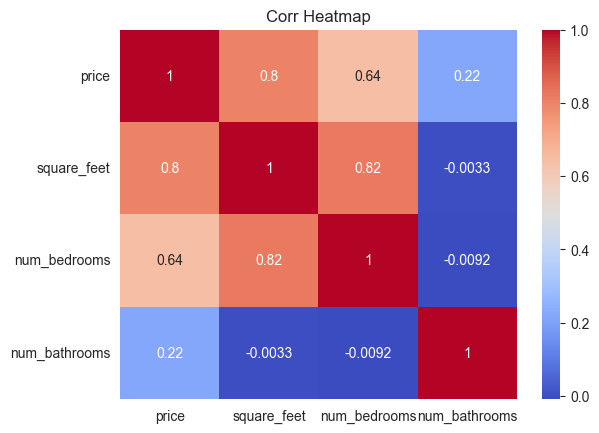

In [13]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Corr Heatmap")
plt.show()

In [14]:
# Fit a multiple linear regression model
X = df[["square_feet", "num_bedrooms", "num_bathrooms"]]
y = df["price"]

# Add constant term (for intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     744.1
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          9.72e-254
Time:                        16:49:55   Log-Likelihood:                -11327.
No. Observations:                1000   AIC:                         2.266e+04
Df Residuals:                     996   BIC:                         2.268e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          5.256e+04   3667.087     14.332

In [15]:
# Check for multicollinearity using VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
print("\nVariance Inflation Factors:\n", vif_data)


Variance Inflation Factors:
          Feature        VIF
0          const  33.177993
1    square_feet   3.039349
2   num_bedrooms   3.039571
3  num_bathrooms   1.000138
